# MEN 02 — Predicting value and RPE from motion energy before the outcome

How well does motion energy (ME) before the outcome predict the behavioral model's value of the
chosen option, Q_chosen, on each trial? Before the outcome the reward is not yet known, so the part of
RPE (= reward − Q_chosen) that video could carry is −Q_chosen; within an outcome class, predicting
Q_chosen and predicting RPE are the same problem. RPE itself, Q_sum and Q_chosen − Q_unchosen are fit
as further targets.

**Before the outcome.** The reward arrives at the first lick after the go cue (the outcome time equals
the choice time), and the median response time is ~0.2 s. Three windows of ME come before it:

- **−2…−1 s** and **−1…0 s** before the go cue: ongoing movement and engagement;
- **response**, go cue → first lick: the response movement.

**Predictor sets.** Response time (log RT) is a behavioral readout of Q_chosen, from the lickometer, and
is fit as a predictor in its own right, alone and with ME. Two more behavioral references: whether
the previous trial was rewarded (Q is a filtered reward history, and pre-cue ME can see the previous
trial's consumption licking), and position in the session. ME enters as the three window means, or as
100-ms bins: 2 s before the go cue alone (*ME binned pre-cue*), and with 0.3 s before the first lick
added (*ME binned*; these last bins also carry RT, see §5).

**Tests.** Every predictor set is fit on its own; ME rows are ME alone. Two levels:

- **Correlation (§2).** Per session, the Pearson r of the target with one window's ME (or log RT) over
  responded trials. Each session is a separate replicate, so the test is whether r has the same sign
  across animals (Wilcoxon signed-rank on animal means). Nothing is removed or assumed about how fast
  Q_chosen or ME vary: a relation carried by slow co-variation within the session counts.
- **Cross-validated decoders (§3–§5).** Per session and camera: ridge regression on z-scored predictors
  (penalty by generalized cross-validation within each training set), scored by cross-validated R²
  over 5 contiguous blocks of trials, against the same fit with the target circularly shifted across
  trials (≥ 20 trials, 100 shifts). This asks more: whether held-out trials are predicted, and whether
  this session's alignment beats misaligned versions of itself. Both penalise a slowly varying
  relation (a block can sit at a different level from the rest, and shifted copies of a slow series
  still correlate by chance), so a relation can pass §2 and fail here.

Responded trials only (Q_chosen is undefined without a choice). Session values are averaged within
animal.

1. ME and RT by Q_chosen: trial averages by Q_chosen tercile, and high − low differences
2. Correlation of each ME window and of RT with Q_chosen
3. Cross-validated decoders of Q_chosen, both cameras
4. RPE, Q_sum and Q_chosen − Q_unchosen
5. When in the trial: the binned decoder's weights
6. One session: Q_chosen and its cross-validated predictions
7. Numbers

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import men_utils as mu
import signal_utils as su
import stats_utils as st
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Degrees of freedom <= 0")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 200)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

# Trial and event tables: the CSV-curated FIP assets (as men_00)
ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
CACHE_PATH = ("/root/capsule/scratch/men_00/sessions.pkl" if IS_CO     # shared with men_00/men_01
              else os.environ.get("MEN_CACHE", "../../data/men_00_cache/sessions.pkl"))
FIG_DIR = "/root/capsule/scratch/figures/men" if IS_CO else "../data/figures/men"
SAVE_FIG = True

# ── Data (as men_00) ─────────────────────────────────────────────────────────
CAMERAS = ("BottomCamera", "SideCameraRight")
EXCLUDE_ACTIONS = ()
FS = 100.0                 # Hz
ME_NORM = "z"              # per session and camera

# ── Trial features ───────────────────────────────────────────────────────────
PRECUE_FAR_WIN = (-2.0, -1.0)   # s around the go cue
PRECUE_WIN = (-1.0, 0.0)   # s around the go cue (men_00's baseline window)
BIN_S = 0.1                # bin width of the binned decoder
PRECUE_BINS = (-2.0, 0.0)  # s around the go cue
PRECHOICE_BINS = (-0.3, 0.0)   # s before the first lick (the outcome)
MIN_TRIALS = 100           # responded trials with every feature, per session and camera

# ── Fits ─────────────────────────────────────────────────────────────────────
N_FOLDS = 5                # contiguous blocks of trials
ALPHAS = np.logspace(-2, 4, 13)   # ridge penalties, chosen by GCV within each training set
N_SHIFT = 100              # circular shifts of the target across trials
MIN_SHIFT_TRIALS = 20

TARGETS = {"Q_chosen": "Q_chosen", "RPE": "RPE_earned", "Q_sum": "Q_sum",
           "Q_chosen − Q_unchosen": "dQ"}

# ── Colors ───────────────────────────────────────────────────────────────────
CAM_LABEL = {"BottomCamera": "Bottom camera", "SideCameraRight": "Side camera"}
TERCILE_COLOR = {"low": OKABE_ITO["sky_blue"], "mid": OKABE_ITO["blue"], "high": "#002b4d"}
SET_COLOR_BEHAV = "0.45"
SET_COLOR_ME = OKABE_ITO["reddish_purple"]
SET_COLOR_BOTH = OKABE_ITO["vermillion"]
rng = np.random.default_rng(0)

## 0. Data

The sessions of `men_00` (its cache), with each camera that passed the ME table's timing and image
screen. ME is z-scored per session and camera.

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

me_index = fu.load_me_index(ME_DATA_ROOT)
inv = mu.inventory_sessions(asset_roots, me_index)
for cam in CAMERAS:
    inv[f"{cam}_used"] = (inv[f"{cam}_status"] == "ok") & ~inv[f"{cam}_action"].isin(EXCLUDE_ACTIONS)
inv["has_trials"] = inv["path"].notna()

sessions = mu.load_sessions(inv[inv.has_trials], fs=FS, cache_path=CACHE_PATH,
                            data_root=ME_DATA_ROOT, cameras=CAMERAS)
used = {(r.ses_idx, cam): bool(getattr(r, f"{cam}_used")) for r in inv.itertuples() for cam in CAMERAS}
for s in sessions:
    s["me_n"] = {cam: (mu.normalise(x, ME_NORM) if x is not None and used[(s["session"], cam)] else None)
                 for cam, x in s["me"].items()}
SUBJECTS = sorted({s["subject"] for s in sessions})
print(f"{len(sessions)} sessions from {len(SUBJECTS)} animals")
for cam in CAMERAS:
    print(f"  {CAM_LABEL[cam]}: {sum(s['me_n'][cam] is not None for s in sessions)} sessions")

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data
loaded 97 sessions from cache ../../data/men_00_cache/sessions.pkl


97 sessions from 9 animals
  Bottom camera: 88 sessions
  Side camera: 64 sessions


### Trial features

One row per responded trial: the targets, log RT (go cue → first lick), the previous trial's outcome,
position in the session, and per camera the three window ME means and the binned ME.
Trials missing any feature for a camera are left out of that camera's fits, so every predictor set
of a camera is fit on the same trials.

In [4]:
PRE_LAGS = np.arange(int(round(PRECUE_BINS[0] * FS)), int(round(PRECUE_BINS[1] * FS))) / FS
CH_LAGS = np.arange(int(round(PRECHOICE_BINS[0] * FS)), int(round(PRECHOICE_BINS[1] * FS))) / FS
PER_BIN = int(round(BIN_S * FS))
PRE_BIN_T = PRE_LAGS[::PER_BIN]          # bin start, s from the go cue
CH_BIN_T = CH_LAGS[::PER_BIN]            # bin start, s from the first lick
BIN_COLS = [f"cue{t:+.1f}" for t in PRE_BIN_T] + [f"lick{t:+.1f}" for t in CH_BIN_T]

SETS = {
    "trial position": ["trial_frac"],
    "previous outcome": ["prev_rewarded"],
    "RT": ["log_rt"],
    "ME −2…−1 s": ["me_far"],
    "ME −1…0 s": ["me_pre"],
    "ME response": ["me_resp"],
    "ME windows": ["me_far", "me_pre", "me_resp"],
    "ME binned pre-cue": [c for c in BIN_COLS if c.startswith("cue")],
    "ME binned": BIN_COLS,
    "ME windows + RT": ["me_far", "me_pre", "me_resp", "log_rt"],
    "ME binned + RT": BIN_COLS + ["log_rt"],
}
SET_COLORS = [SET_COLOR_BEHAV] * 3 + [SET_COLOR_ME] * 6 + [SET_COLOR_BOTH] * 2


def binned(x, t0, times, lags):
    # (n_trials, n_bins): ME averaged in BIN_S bins at these lags from each time
    seg = su.peri_event_grid(x, t0, FS, times, lags)
    return np.nanmean(seg.reshape(len(times), -1, PER_BIN), axis=2)


def trial_table(s, cam):
    # one row per responded trial with every feature for this camera, or None
    tr = s["trials"].reset_index(drop=True)
    x = s["me_n"][cam]
    if x is None:
        return None
    df = pd.DataFrame(dict(
        trial=tr["trial"], Q_chosen=tr["Q_chosen"], RPE_earned=tr["RPE_earned"], Q_sum=tr["Q_sum"],
        dQ=tr["Q_chosen"] - tr["Q_unchosen"],
        rewarded=(tr["earned_reward"].fillna(0) > 0).astype(float),
        trial_frac=np.arange(len(tr)) / max(len(tr) - 1, 1),
    ))
    df["prev_rewarded"] = df["rewarded"].shift(1).fillna(0)
    cue = tr["goCue_start_time_in_session"].to_numpy()
    choice = tr["choice_time_in_session"].to_numpy()
    rt = choice - cue
    df["rt"] = rt
    df["log_rt"] = np.log(np.where(rt > 0, rt, np.nan))
    df["me_far"] = su.window_mean_grid(x, s["t0"], FS, cue, *PRECUE_FAR_WIN)
    df["me_pre"] = su.window_mean_grid(x, s["t0"], FS, cue, *PRECUE_WIN)
    df["me_resp"] = su.window_mean_grid(x, s["t0"], FS, cue, 0.0, rt)   # go cue → first lick
    df[BIN_COLS] = np.c_[binned(x, s["t0"], cue, PRE_LAGS), binned(x, s["t0"], choice, CH_LAGS)]
    responded = (tr["animal_response"] < 2).to_numpy()
    need = ["Q_chosen", "RPE_earned", "Q_sum", "dQ", "log_rt", "me_far", "me_pre", "me_resp"] + BIN_COLS
    df = df[responded & np.isfinite(df[need].to_numpy(float)).all(axis=1)].reset_index(drop=True)
    if len(df) < MIN_TRIALS:
        return None
    df.insert(0, "subject", s["subject"])
    df.insert(1, "session", s["session"])
    df.insert(2, "camera", cam)
    return df


tables = {(s["session"], cam): t for s in sessions for cam in CAMERAS
          if (t := trial_table(s, cam)) is not None}
for cam in CAMERAS:
    n = [len(t) for (_, c), t in tables.items() if c == cam]
    print(f"{CAM_LABEL[cam]}: {len(n)} sessions, median {np.median(n):.0f} trials")

Bottom camera: 88 sessions, median 477 trials
Side camera: 64 sessions, median 488 trials


### The fit

`ridge_cv` z-scores the predictors on each training block, picks the ridge penalty by generalized
cross-validation on it, and predicts the held-out block. It takes the observed target and its
circular shifts as columns of one matrix, so the null costs one more matrix product per penalty.

In [5]:
def ridge_gcv(X, Y):
    # X (n, p) z-scored, Y (n, k) centred -> coefficients (p, k) at each column's GCV-best penalty
    U, sv, Vt = np.linalg.svd(X, full_matrices=False)
    UtY = U.T @ Y
    n = len(X)
    best = np.full(Y.shape[1], np.inf)
    coef = np.zeros((X.shape[1], Y.shape[1]))
    for a in ALPHAS:
        d = sv / (sv ** 2 + a)
        fit = U @ ((sv * d)[:, None] * UtY)
        gcv = np.mean((Y - fit) ** 2, axis=0) / (1 - np.sum(sv ** 2 / (sv ** 2 + a)) / n) ** 2
        better = gcv < best
        if better.any():
            coef[:, better] = Vt.T @ (d[:, None] * UtY[:, better])
            best[better] = gcv[better]
    return coef


def zscore_on(train, *others):
    mu, sd = train.mean(0), train.std(0)
    sd[sd == 0] = 1.0
    return [(a - mu) / sd for a in (train, *others)]


def ridge_cv(X, Y):
    # cross-validated predictions of each column of Y over N_FOLDS contiguous blocks
    pred = np.empty_like(Y)
    for test in np.array_split(np.arange(len(X)), N_FOLDS):
        train = np.ones(len(X), bool)
        train[test] = False
        Xtr, Xte = zscore_on(X[train], X[test])
        ym = Y[train].mean(0)
        pred[test] = Xte @ ridge_gcv(Xtr, Y[train] - ym) + ym
    return pred


def cv_r2(y_cols, pred):
    return 1 - ((y_cols - pred) ** 2).sum(0) / ((y_cols - y_cols.mean(0)) ** 2).sum(0)


def shifted(y, shifts):
    # (n, 1 + n_shift): the target, then its circular shifts across trials
    return np.column_stack([y] + [np.roll(y, k) for k in shifts])

In [6]:
rows, coef_rows = [], []
for (ses, cam), df in tables.items():
    shifts = rng.integers(MIN_SHIFT_TRIALS, len(df) - MIN_SHIFT_TRIALS, N_SHIFT)
    for tname, tcol in TARGETS.items():
        Y = shifted(df[tcol].to_numpy(float), shifts)
        for sname, cols in SETS.items():
            r2 = cv_r2(Y, ridge_cv(df[cols].to_numpy(float), Y))
            rows.append(dict(subject=df.subject[0], session=ses, camera=cam, target=tname, set=sname,
                             n_trials=len(df), r2=r2[0], null=np.median(r2[1:]),
                             effect=r2[0] - np.median(r2[1:]), p=st.shift_p(r2[0], r2[1:])))
        # weights of the binned decoder fit on every trial (z-scored predictors)
        Xz = zscore_on(df[BIN_COLS].to_numpy(float))[0]
        y = df[tcol].to_numpy(float)
        coef_rows.append(dict(subject=df.subject[0], session=ses, camera=cam, target=tname,
                              coef=ridge_gcv(Xz, (y - y.mean())[:, None])[:, 0] / y.std()))

fits = pd.DataFrame(rows)
coefs = pd.DataFrame(coef_rows)


def animal_table(cam, target, value="effect"):
    # animals x predictor sets
    w = fits[(fits.camera == cam) & (fits.target == target)].pivot_table(
        index=["subject", "session"], columns="set", values=value).reset_index()
    return st.animal_means(w, list(SETS), by_session=False)[list(SETS)]


print(f"{fits.groupby('camera').session.nunique().to_dict()} sessions fit")
fits.groupby(["camera", "target", "set"], sort=False).agg(
    r2=("r2", "median"), null=("null", "median"), effect=("effect", "median"),
    sessions_p05=("p", lambda p: f"{(p < 0.05).sum()}/{len(p)}")).round(3)

{'BottomCamera': 88, 'SideCameraRight': 64} sessions fit


r2   null  effect sessions_p05
camera          target                set                                                 
BottomCamera    Q_chosen              trial position    -0.067 -0.091   0.003        10/88
                                      previous outcome   0.415 -0.046   0.475        84/88
                                      RT                 0.011 -0.051   0.060        52/88
                                      ME −2…−1 s        -0.025 -0.047   0.015        41/88
                                      ME −1…0 s         -0.032 -0.047   0.008        31/88
                                      ME response       -0.049 -0.049  -0.000        14/88
                                      ME windows        -0.019 -0.052   0.029        44/88
                                      ME binned pre-cue -0.027 -0.049   0.017        38/88
                                      ME binned          0.011 -0.053   0.071        58/88
                                      ME windows + RT    0.046 -0.053   0.105        62/88
                                      ME binned + RT     0.033 -0.056   0.101        63/88
                RPE                   trial position    -0.001 -0.001   0.000         6/88
                                      previous outcome   0.058 -0.002   0.059        75/88
                                      RT                 0.011 -0.002   0.015        60/88
                                      ME −2…−1 s        -0.002 -0.002  -0.000        14/88
                                      ME −1…0 s         -0.003 -0.002   0.000        15/88
                                      ME response       -0.002 -0.002   0.000        14/88
                                      ME windows        -0.003 -0.002  -0.000        23/88
                                      ME binned pre-cue -0.004 -0.003  -0.001        12/88
                                      ME binned         -0.002 -0.003   0.002        33/88
                                      ME windows + RT    0.011 -0.002   0.016        56/88
                                      ME binned + RT     0.000 -0.003   0.005        44/88
                Q_sum                 trial position    -0.075 -0.098   0.002        10/88
                                      previous outcome   0.483 -0.051   0.524        84/88
                                      RT                -0.008 -0.054   0.034        43/88
                                      ME −2…−1 s        -0.026 -0.051   0.017        43/88
                                      ME −1…0 s         -0.029 -0.051   0.012        32/88
                                      ME response       -0.052 -0.054  -0.001        15/88
                                      ME windows        -0.019 -0.057   0.026        44/88
                                      ME binned pre-cue -0.019 -0.053   0.022        40/88
                                      ME binned          0.008 -0.059   0.075        53/88
                                      ME windows + RT    0.021 -0.061   0.076        60/88
                                      ME binned + RT     0.003 -0.059   0.086        58/88
                Q_chosen − Q_unchosen trial position    -0.052 -0.071   0.005         9/88
                                      previous outcome   0.303 -0.040   0.353        84/88
                                      RT                 0.025 -0.041   0.061        54/88
                                      ME −2…−1 s        -0.022 -0.039   0.009        36/88
                                      ME −1…0 s         -0.029 -0.038   0.006        31/88
                                      ME response       -0.041 -0.040  -0.003        18/88
                                      ME windows        -0.020 -0.041   0.019        40/88
                                      ME binned pre-cue -0.025 -0.041   0.009        32/88
                                      ME binned          0.004 -0.046   0.066        54/88
                                      ME windows + RT   

## 1. ME and RT by Q_chosen

Responded trials split into Q_chosen terciles within each session. **a–b** ME around the go cue
(censored at the first lick, so nothing after the outcome enters) and before the first lick, per
camera. **c** High − low tercile difference of log RT and of each window's ME mean, one point per
animal.

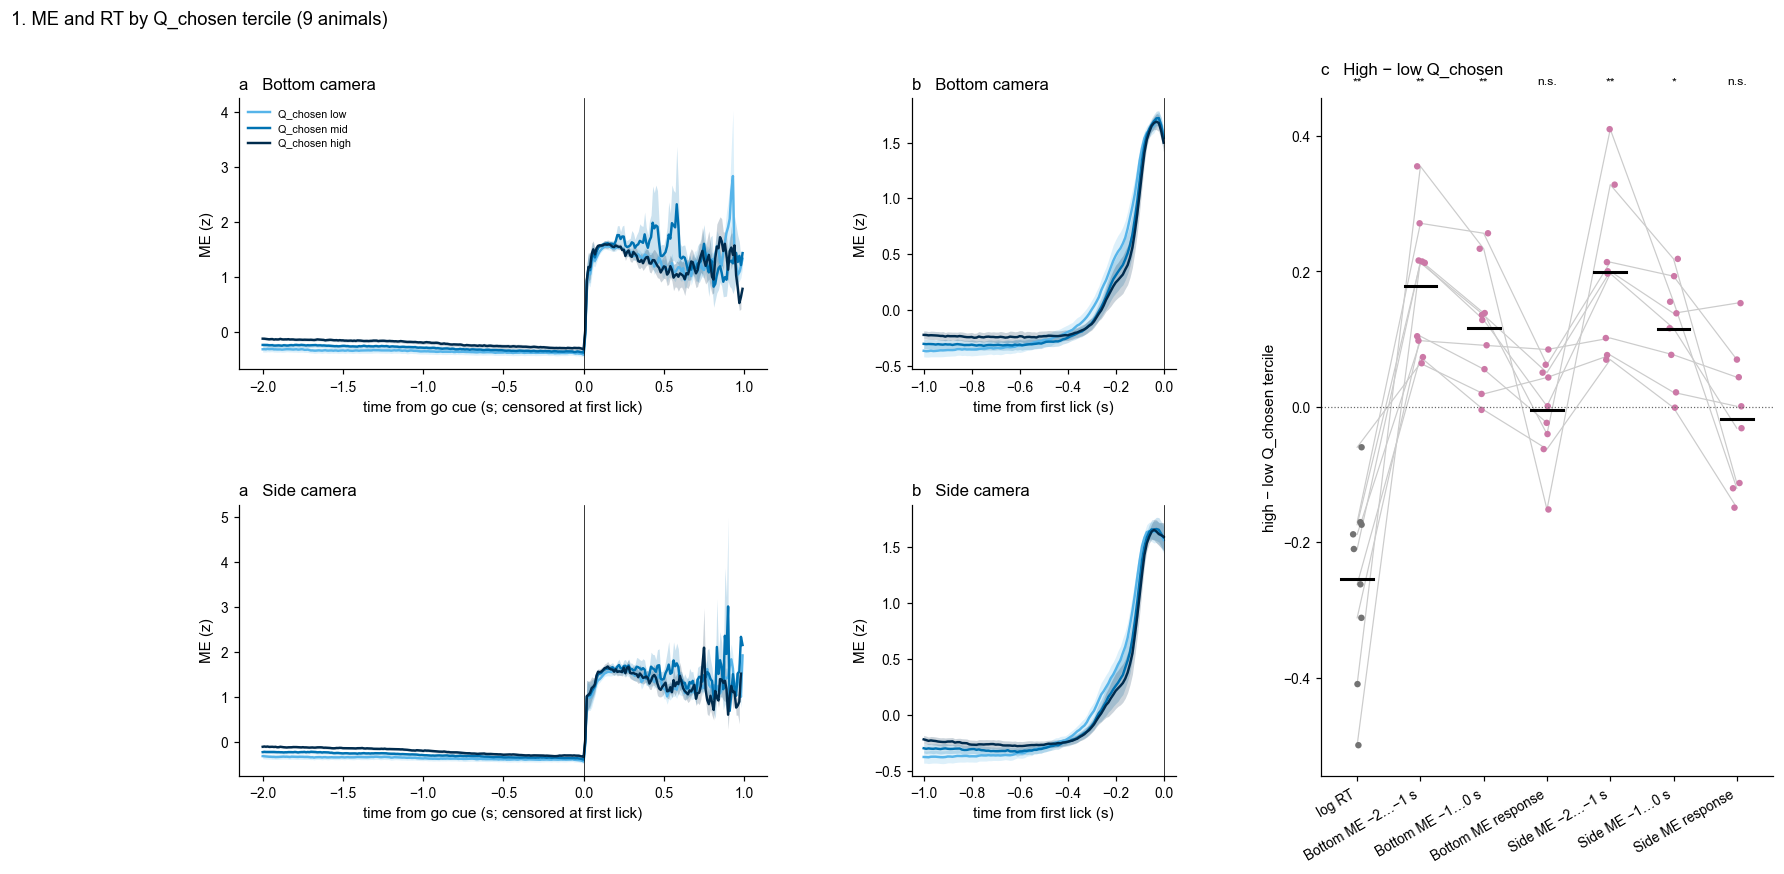

In [7]:
CUE_LAGS = np.arange(-2.0, 1.0 + 1e-9, 1 / FS)
LICK_LAGS = np.arange(-1.0, 0.0 + 1e-9, 1 / FS)
TERC = list(TERCILE_COLOR)

eta = {(cam, al, t): [] for cam in CAMERAS for al in ("cue", "lick") for t in TERC}
diff_rows = []
by_session = {s["session"]: s for s in sessions}
for (ses, cam), df in tables.items():
    s = by_session[ses]
    tr = s["trials"].set_index("trial").loc[df.trial]
    cue = tr["goCue_start_time_in_session"].to_numpy()
    choice = tr["choice_time_in_session"].to_numpy()
    terc = pd.qcut(df.Q_chosen.rank(method="first"), 3, labels=TERC).to_numpy()
    x = s["me_n"][cam]
    seg_cue = su.peri_event_grid(x, s["t0"], FS, cue, CUE_LAGS, censor_after=choice)
    seg_lick = su.peri_event_grid(x, s["t0"], FS, choice, LICK_LAGS)
    for t in TERC:
        eta[(cam, "cue", t)].append((df.subject[0], np.nanmean(seg_cue[terc == t], 0)))
        eta[(cam, "lick", t)].append((df.subject[0], np.nanmean(seg_lick[terc == t], 0)))
    hi, lo = terc == "high", terc == "low"
    r = dict(subject=df.subject[0], session=ses)
    for c in ("log_rt", "me_far", "me_pre", "me_resp"):
        r[f"{cam}|{c}"] = df[c][hi].mean() - df[c][lo].mean()
    diff_rows.append(r)

diffs = pd.DataFrame(diff_rows).groupby(["subject", "session"]).first().reset_index()
diffs["log_rt"] = diffs[[f"{c}|log_rt" for c in CAMERAS]].mean(axis=1)   # same trials up to screening
diff_cols = ["log_rt"] + [f"{cam}|{c}" for cam in CAMERAS for c in ("me_far", "me_pre", "me_resp")]
diff_animal = st.animal_means(diffs, diff_cols, by_session=False)


def animal_traces(per_session):
    subj, traces = zip(*per_session)
    return st.group_means(traces, subj)[1]


fig = plt.figure(figsize=(18, 8))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1.4, 0.7, 1.2], hspace=0.5, wspace=0.35, top=0.88)
for r, cam in enumerate(CAMERAS):
    for c, (al, lags, xlab) in enumerate((("cue", CUE_LAGS, "time from go cue (s; censored at first lick)"),
                                          ("lick", LICK_LAGS, "time from first lick (s)"))):
        ax = fig.add_subplot(gs[r, c])
        if eta[(cam, al, "low")]:
            for t in TERC:
                pu.plot_mean_sem(ax, lags, animal_traces(eta[(cam, al, t)]), TERCILE_COLOR[t],
                                 f"Q_chosen {t}")
        ax.axvline(0, color="k", lw=0.5)
        ax.set_xlabel(xlab)
        ax.set_ylabel("ME (z)")
        ax.set_title(f"{'ab'[c]}   {CAM_LABEL[cam]}", loc="left")
        if c == 0 and r == 0:
            ax.legend(fontsize=7)
        style_ax(ax)
ax = fig.add_subplot(gs[:, 2])
labels = ["log RT"] + [f"{CAM_LABEL[cam].split()[0]} ME {w}" for cam in CAMERAS for w in ("−2…−1 s", "−1…0 s", "response")]
pu.strip_by_measure(ax, diff_animal, diff_cols, labels, [SET_COLOR_BEHAV] + [SET_COLOR_ME] * 6,
                    "high − low Q_chosen tercile", title="c   High − low Q_chosen", rng=rng)
fig.suptitle(f"1. ME and RT by Q_chosen tercile ({len(SUBJECTS)} animals)", x=0.01, ha="left")
save_fig(fig, "men_02_1_terciles", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. Correlation of each ME window and of RT with Q_chosen

Per session, the Pearson r of Q_chosen with each window's ME and with log RT, one point per animal
(mean over its sessions). Stars: Wilcoxon signed-rank of the animal means against 0. ME is used
alone; nothing else is in the fit.

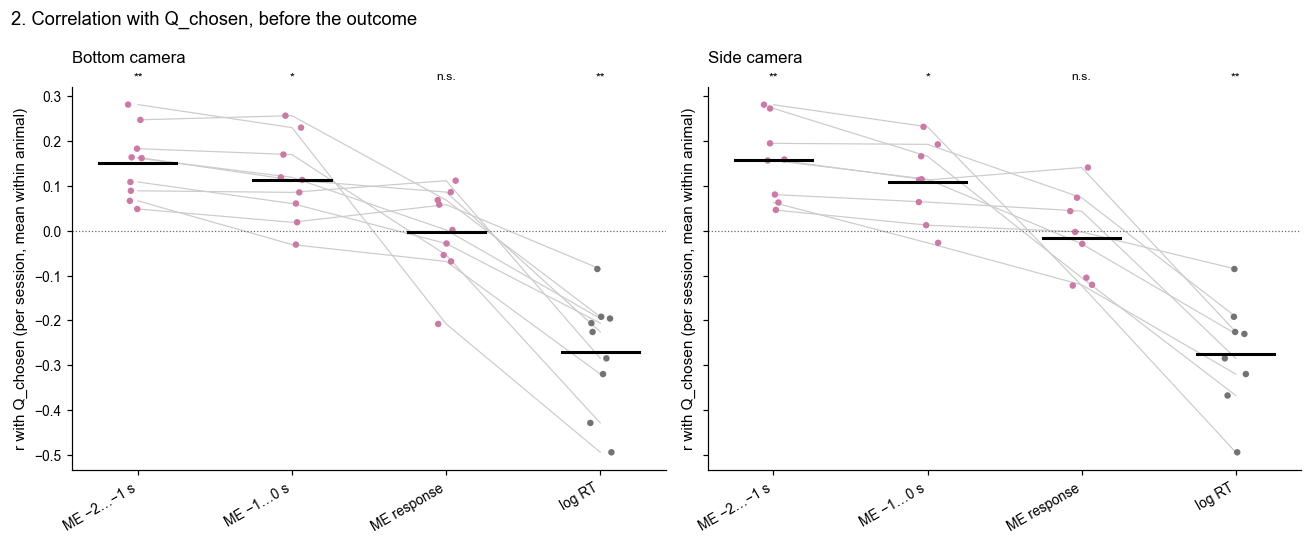

── Bottom camera: sessions with r > 0
predictor
ME −2…−1 s     80/88
ME −1…0 s      78/88
ME response    47/88
log RT          6/88
── Side camera: sessions with r > 0
predictor
ME −2…−1 s     59/64
ME −1…0 s      57/64
ME response    33/64
log RT          6/64


In [8]:
CORR_PRED = {"ME −2…−1 s": "me_far", "ME −1…0 s": "me_pre", "ME response": "me_resp", "log RT": "log_rt"}
CORR_COLORS = [SET_COLOR_ME] * 3 + [SET_COLOR_BEHAV]
corr = pd.DataFrame([
    dict(subject=df.subject[0], session=ses, camera=cam, target=tname, predictor=lab,
         r=np.corrcoef(df[c], df[tcol])[0, 1], n_trials=len(df))
    for (ses, cam), df in tables.items() for tname, tcol in TARGETS.items()
    for lab, c in CORR_PRED.items()])


def corr_animal(cam, target):
    # animals x predictors, mean r over sessions
    w = corr[(corr.camera == cam) & (corr.target == target)].pivot_table(
        index=["subject", "session"], columns="predictor", values="r").reset_index()
    return st.animal_means(w, list(CORR_PRED), by_session=False)[list(CORR_PRED)]


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, cam in zip(axes, CAMERAS):
    pu.strip_by_measure(ax, corr_animal(cam, "Q_chosen"), list(CORR_PRED), list(CORR_PRED), CORR_COLORS,
                        "r with Q_chosen (per session, mean within animal)", title=CAM_LABEL[cam], rng=rng)
fig.suptitle("2. Correlation with Q_chosen, before the outcome", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "men_02_2_q_chosen_corr", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
for cam in CAMERAS:
    sub = corr[(corr.camera == cam) & (corr.target == "Q_chosen")]
    print(f"── {CAM_LABEL[cam]}: sessions with r > 0")
    print(sub.groupby("predictor", sort=False).r.agg(lambda r: f"{(r > 0).sum()}/{len(r)}").to_string())

## 3. Cross-validated decoders of Q_chosen

Cross-validated R² minus the median R² with Q_chosen circularly shifted across trials, one point per
animal, per camera. Grey: behavioral predictors; purple: ME; vermillion: ME + RT. The behavioral
sets do not use the camera; they differ between the panels only through which sessions and trials
have usable ME.

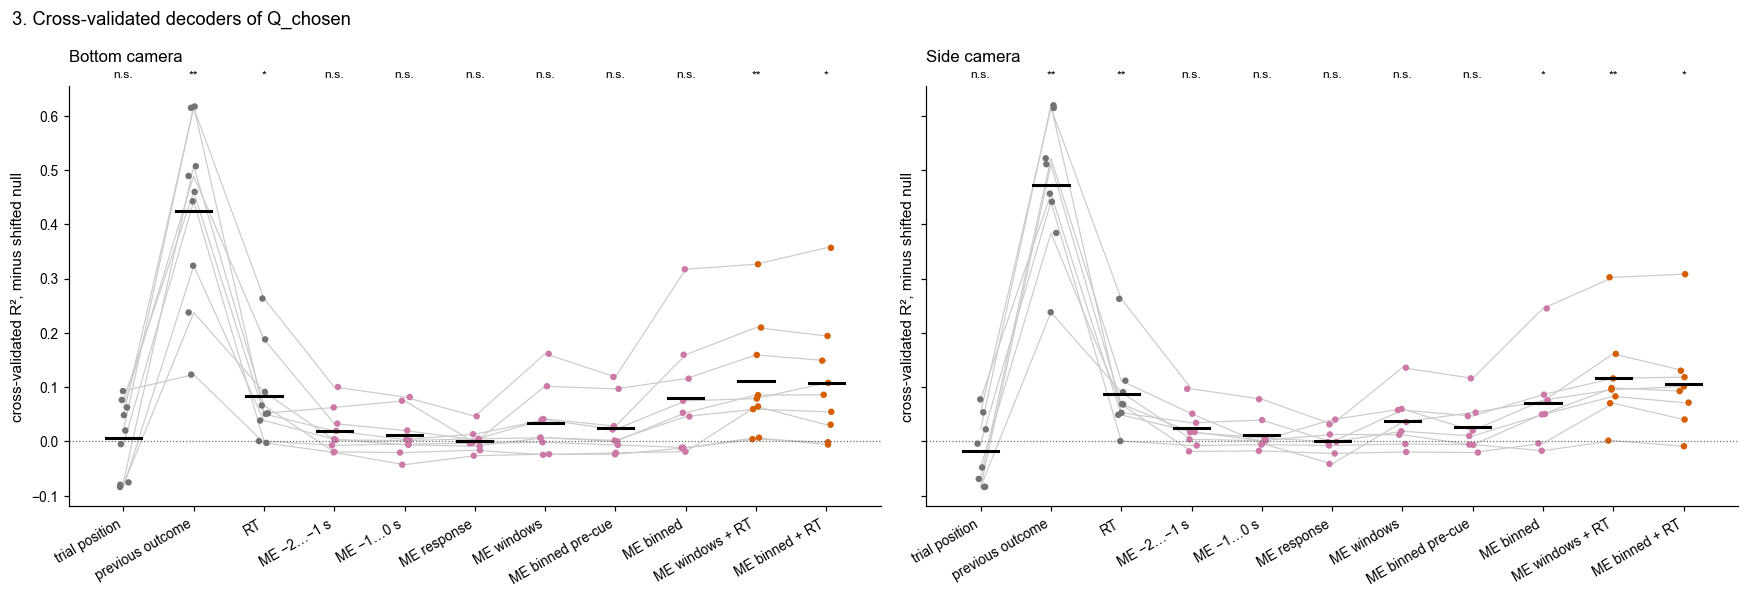

── Bottom camera, Q_chosen, r2 (mean over animals)
 trial position  previous outcome     RT  ME −2…−1 s  ME −1…0 s  ME response  ME windows  ME binned pre-cue  ME binned  ME windows + RT  ME binned + RT
        -0.1152            0.3642 0.0218     -0.0382    -0.0463      -0.0591     -0.0273            -0.0364     0.0157           0.0459          0.0424
── Bottom camera, Q_chosen, null (mean over animals)
 trial position  previous outcome      RT  ME −2…−1 s  ME −1…0 s  ME response  ME windows  ME binned pre-cue  ME binned  ME windows + RT  ME binned + RT
        -0.1214           -0.0595 -0.0613     -0.0578    -0.0583      -0.0603     -0.0616            -0.0604    -0.0647          -0.0646         -0.0656
── Bottom camera, Q_chosen, effect (mean over animals)
 trial position  previous outcome     RT  ME −2…−1 s  ME −1…0 s  ME response  ME windows  ME binned pre-cue  ME binned  ME windows + RT  ME binned + RT
         0.0063            0.4237 0.0831      0.0196      0.012       0.0012   

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, cam in zip(axes, CAMERAS):
    pu.strip_by_measure(ax, animal_table(cam, "Q_chosen"), list(SETS), list(SETS), SET_COLORS,
                        "cross-validated R², minus shifted null", title=CAM_LABEL[cam], rng=rng)
fig.suptitle("3. Cross-validated decoders of Q_chosen", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "men_02_3_q_chosen_cv", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
for cam in CAMERAS:
    for value in ("r2", "null", "effect"):
        print(f"── {CAM_LABEL[cam]}, Q_chosen, {value} (mean over animals)")
        print(animal_table(cam, "Q_chosen", value).mean().round(4).to_frame().T.to_string(index=False))

## 4. RPE, Q_sum and Q_chosen − Q_unchosen

As §3 for the other targets. RPE contains the reward, which no pre-outcome predictor can know; its
predictable part is −Q_chosen.

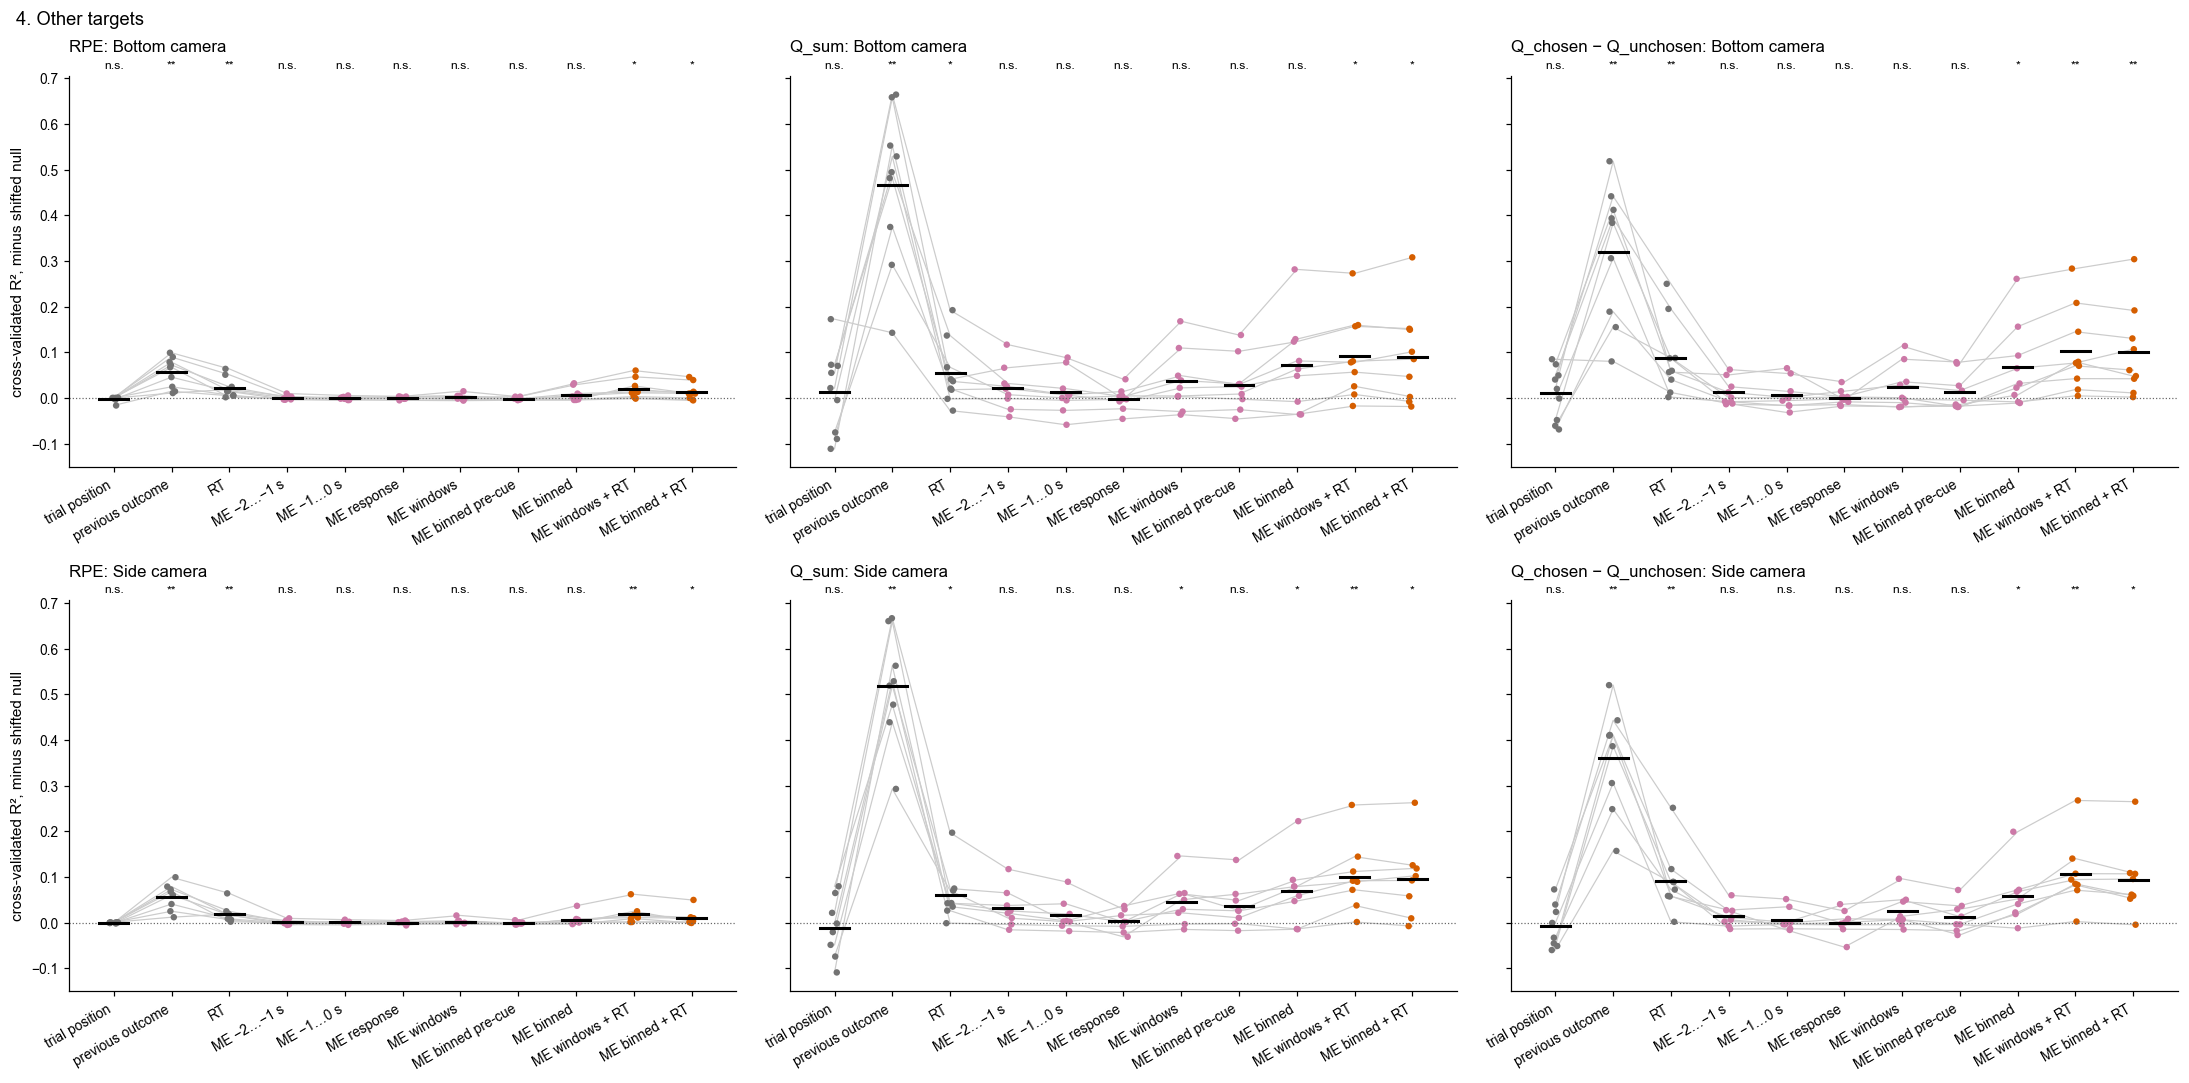

In [10]:
others = [t for t in TARGETS if t != "Q_chosen"]
fig, axes = plt.subplots(len(CAMERAS), len(others), figsize=(20, 10), sharey=True)
for r, cam in enumerate(CAMERAS):
    for c, tname in enumerate(others):
        pu.strip_by_measure(axes[r, c], animal_table(cam, tname), list(SETS), list(SETS), SET_COLORS,
                            "cross-validated R², minus shifted null" if c == 0 else "",
                            title=f"{tname}: {CAM_LABEL[cam]}", rng=rng)
fig.suptitle("4. Other targets", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "men_02_4_other_targets", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. When in the trial

Weights of the binned decoder fit on every trial of a session (ME bins z-scored, weights in SD of the
target per SD of ME), averaged within animal; mean ± SEM over animals. Left: bins before the go
cue; right: bins before the first lick. With correlated neighbouring bins, the ridge penalty
spreads weight across them, so the profile shows where the information sits, not single-bin effects.

The bins before the first lick also carry response time: on a fast trial they reach back past the go
cue into the quieter pre-cue period, and fast trials are high-Q_chosen trials (§1). *ME binned
pre-cue* (§3) leaves them out and so holds no RT information.

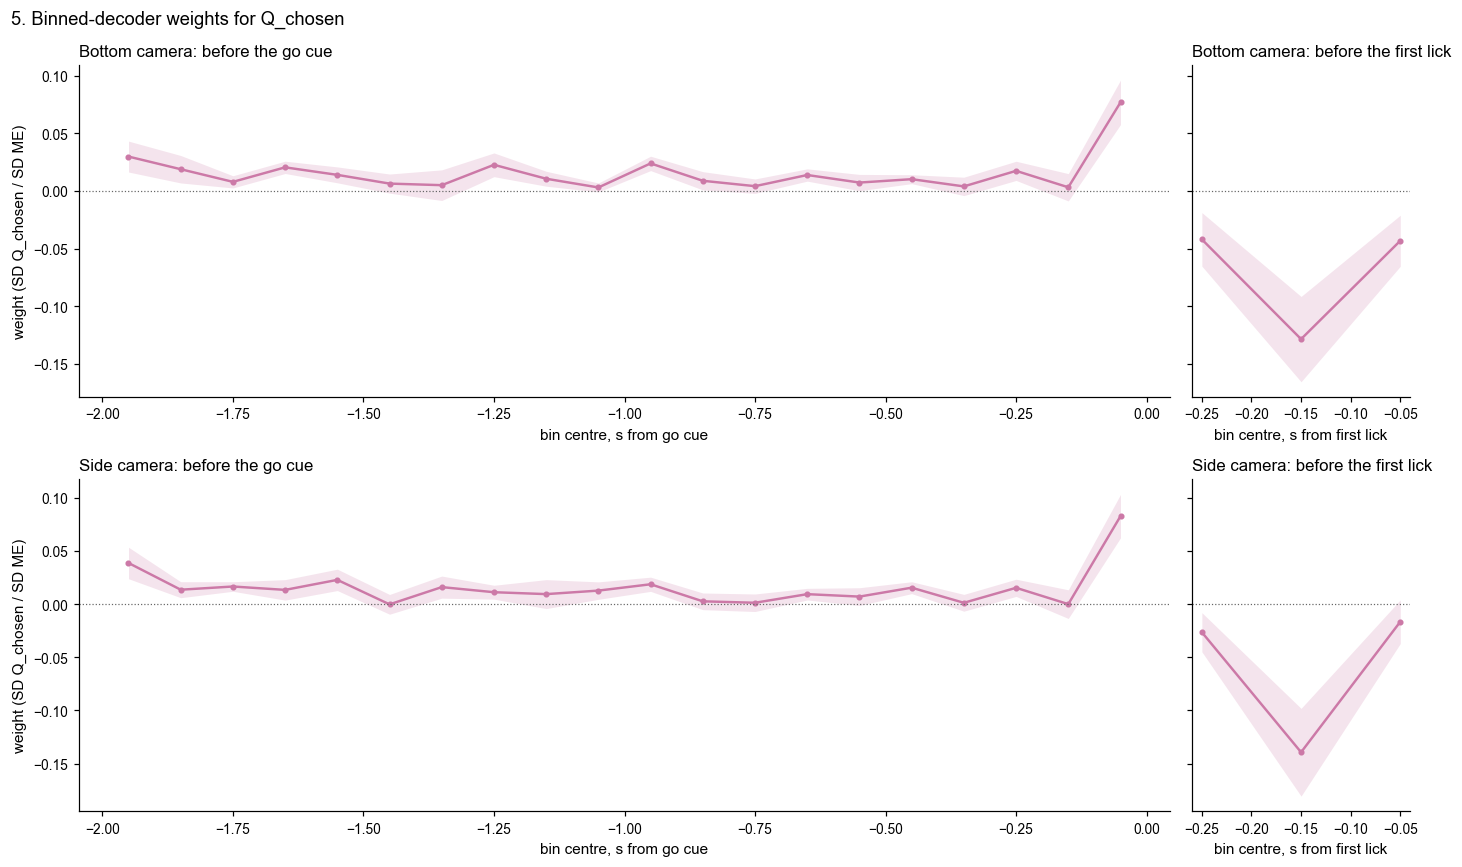

In [11]:
n_pre = len(PRE_BIN_T)
fig, axes = plt.subplots(len(CAMERAS), 2, figsize=(13, 8), sharey="row",
                         gridspec_kw=dict(width_ratios=[n_pre, max(len(CH_BIN_T), 4)]))
for r, cam in enumerate(CAMERAS):
    sub = coefs[(coefs.camera == cam) & (coefs.target == "Q_chosen")]
    if sub.empty:
        continue
    curves = st.group_means(list(sub.coef), list(sub.subject))[1]
    for c, (x, sl, lab) in enumerate(((PRE_BIN_T + BIN_S / 2, slice(0, n_pre), "go cue"),
                                      (CH_BIN_T + BIN_S / 2, slice(n_pre, None), "first lick"))):
        ax = axes[r, c]
        pu.plot_mean_sem(ax, x, curves[:, sl], SET_COLOR_ME, "Q_chosen")
        ax.plot(x, curves[:, sl].mean(0), "o", color=SET_COLOR_ME, ms=3)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_xlabel(f"bin centre, s from {lab}")
        if c == 0:
            ax.set_ylabel("weight (SD Q_chosen / SD ME)")
        ax.set_title(f"{CAM_LABEL[cam]}: before the {lab}", loc="left")
        style_ax(ax)
fig.suptitle("5. Binned-decoder weights for Q_chosen", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "men_02_5_weights", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. One session

Bottom camera, the session whose *ME binned* effect for Q_chosen is closest to the median: Q_chosen
over trials with the cross-validated predictions of RT, ME binned and ME binned + RT.

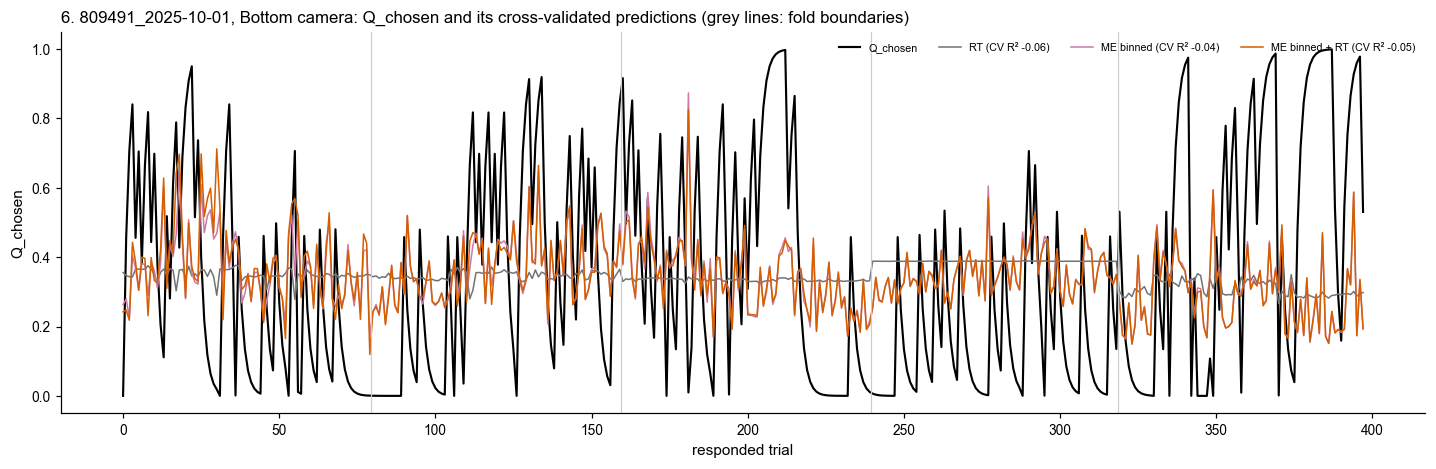

In [12]:
cam = "BottomCamera"
sel = fits[(fits.camera == cam) & (fits.target == "Q_chosen") & (fits.set == "ME binned")].reset_index(drop=True)
ex = sel.iloc[int(np.argmin(np.abs(sel.effect - sel.effect.median())))]
df = tables[(ex.session, cam)]
y = df["Q_chosen"].to_numpy(float)
fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(np.arange(len(y)), y, color="k", lw=1.4, label="Q_chosen")
for sname, color in (("RT", SET_COLOR_BEHAV), ("ME binned", SET_COLOR_ME), ("ME binned + RT", SET_COLOR_BOTH)):
    pred = ridge_cv(df[SETS[sname]].to_numpy(float), y[:, None])[:, 0]
    r2 = fits[(fits.session == ex.session) & (fits.camera == cam) & (fits.target == "Q_chosen")
              & (fits.set == sname)].r2.iloc[0]
    ax.plot(np.arange(len(y)), pred, color=color, lw=1.0, label=f"{sname} (CV R² {r2:.2f})")
for b in np.array_split(np.arange(len(y)), N_FOLDS)[1:]:
    ax.axvline(b[0] - 0.5, color="0.8", lw=0.8)
ax.set_xlabel("responded trial")
ax.set_ylabel("Q_chosen")
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.set_title(f"6. {ex.session}, {CAM_LABEL[cam]}: Q_chosen and its cross-validated predictions "
             f"(grey lines: fold boundaries)", loc="left")
style_ax(ax)
save_fig(fig, "men_02_6_example", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 7. Numbers

Correlations (§2): per camera, target and predictor, the mean r over animals, Wilcoxon p, animals
and sessions with r > 0. Decoders (§3–§4): per camera, target and predictor set: mean over animals of the cross-validated R², its shifted null
and their difference; Wilcoxon p of the difference against zero; animals with a positive difference;
sessions whose R² beats 95% of their shifts.

In [13]:
S = []
for cam in CAMERAS:
    for tname in TARGETS:
        eff = animal_table(cam, tname)
        r2 = animal_table(cam, tname, "r2")
        null = animal_table(cam, tname, "null")
        sub = fits[(fits.camera == cam) & (fits.target == tname)]
        for sname in SETS:
            m, p, n = st.wilcoxon_animals(eff[sname])
            ps = sub[sub.set == sname].p
            S.append(dict(camera=CAM_LABEL[cam], target=tname, set=sname, r2=round(r2[sname].mean(), 3),
                          null=round(null[sname].mean(), 3), effect=round(m, 3), p=round(p, 4),
                          animals_positive=f"{int((eff[sname] > 0).sum())}/{n}",
                          sessions_p05=f"{(ps < 0.05).sum()}/{len(ps)}"))
numbers = pd.DataFrame(S)

C = []
for cam in CAMERAS:
    for tname in TARGETS:
        ca = corr_animal(cam, tname)
        sub = corr[(corr.camera == cam) & (corr.target == tname)]
        for lab in CORR_PRED:
            m, p, n = st.wilcoxon_animals(ca[lab])
            rs = sub[sub.predictor == lab].r
            C.append(dict(camera=CAM_LABEL[cam], target=tname, predictor=lab, r=round(m, 3), p=round(p, 4),
                          animals_positive=f"{int((ca[lab] > 0).sum())}/{n}",
                          sessions_positive=f"{(rs > 0).sum()}/{len(rs)}"))
correlations = pd.DataFrame(C)
display(correlations)
numbers

,camera,target,predictor,r,p,animals_positive,sessions_positive
0,Bottom camera,Q_chosen,ME −2…−1 s,0.150,0.0039,9/9,80/88
1,Bottom camera,Q_chosen,ME −1…0 s,0.114,0.0117,8/9,78/88
2,Bottom camera,Q_chosen,ME response,-0.004,0.8203,5/9,47/88
3,Bottom camera,Q_chosen,log RT,-0.270,0.0039,0/9,6/88
4,Bottom camera,RPE,ME −2…−1 s,-0.032,0.0039,0/9,26/88
5,Bottom camera,RPE,ME −1…0 s,-0.011,0.4258,3/9,35/88
6,Bottom camera,RPE,ME response,0.003,0.8203,5/9,46/88
7,Bottom camera,RPE,log RT,0.154,0.0039,9/9,84/88
8,Bottom camera,Q_sum,ME −2…−1 s,0.167,0.0039,9/9,85/88
9,Bottom camera,Q_sum,ME −1…0 s,0.136,0.0039,9/9,83/88


,camera,target,set,r2,null,effect,p,animals_positive,sessions_p05
0,Bottom camera,Q_chosen,trial position,-0.115,-0.121,0.006,0.9102,5/9,10/88
1,Bottom camera,Q_chosen,previous outcome,0.364,-0.059,0.424,0.0039,9/9,84/88
2,Bottom camera,Q_chosen,RT,0.022,-0.061,0.083,0.0117,8/9,52/88
3,Bottom camera,Q_chosen,ME −2…−1 s,-0.038,-0.058,0.020,0.3008,6/9,41/88
4,Bottom camera,Q_chosen,ME −1…0 s,-0.046,-0.058,0.012,0.8203,5/9,31/88
5,Bottom camera,Q_chosen,ME response,-0.059,-0.060,0.001,0.9102,4/9,14/88
6,Bottom camera,Q_chosen,ME windows,-0.027,-0.062,0.034,0.1641,6/9,44/88
7,Bottom camera,Q_chosen,ME binned pre-cue,-0.036,-0.060,0.024,0.3008,6/9,38/88
8,Bottom camera,Q_chosen,ME binned,0.016,-0.065,0.080,0.0547,6/9,58/88
9,Bottom camera,Q_chosen,ME windows + RT,0.046,-0.065,0.111,0.0039,9/9,62/88
